In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt 
import plotly.express as px

In [3]:
data = pd.read_csv("~/Desktop/L3MIASHS/Stage/BdAPI.csv")


# Dictionnaire pour raccourcir les noms des colonnes
noms_colonnes = {
    "Année": "Année",
    "Pays": "Pays",
    "Code Pays": "Code_Pays",
    "Espérance de vie à la naissance, hommes (années)": "LE_hommes",
    "Espérance de vie à la naissance, femmes (années)": "LE_femmes",
    "Espérance de vie à la naissance à 60 ans, femmes (années)": "LE_60_femmes",
    "Espérance de vie à la naissance à 60 ans, hommes (années)": "LE_60_hommes",
    "Taux de mortalité infantile, filles (pour 1 000 naissances vivantes)": "Mort_inf_filles",
    "Taux de mortalité infantile, garçons (pour 1 000 naissances vivantes)": "Mort_inf_garçons",
    "PIB par habitant ($ US courants)": "PIB_habitant",
    "Gini index": "Gini",
    "Taux de mortalité, adultes, hommes (pour 1 000 hommes adultes)": "Mort_adultes_hommes",
    "Taux de mortalité, adultes, femmes (pour 1 000 femmes adultes)": "Mort_adultes_femmes",
    "Chômage, femmes (% de la population active féminine)": "Chomage_femmes",
    "Chômage, hommes (% de la population active masculine)": "Chomage_hommes",
    "Émissions de CO2 par habitant (tonnes)": "CO2_habitant",
    "Taux de naissance, brut (pour 1 000 personnes)": "Taux_naissance",
    "Population âgée de 15 à 64 ans, hommes": "Pop_15_64_hommes",
    "Population âgée de 15 à 64 ans, femmes": "Pop_15_64_femmes",
    "Dépenses de santé actuelles (% du PIB)": "Dep_sante_PIB",
    "Mortalité prématurée par maladies cardiovasculaires, cancer, diabète ou maladies respiratoires chroniques (femmes, 30-70 ans)": "Mort_prem_femmes",
    "Mortalité prématurée par maladies cardiovasculaires, cancer, diabète ou maladies respiratoires chroniques (hommes, 30-70 ans)": "Mort_prem_hommes",
    "Incidence du VIH (% de la population de 15 à 49 ans)": "Incidence_VIH",
    "Prévalence du VIH, total (% de la population âgée de 15 à 49 ans)": "Prevalence_VIH",
    "Population âgée de 0 à 4 ans, filles (% de la population féminine)": "Pop_0_4_filles",
    "Population âgée de 0 à 4 ans, garçons (% de la population masculine)": "Pop_0_4_garçons",
    "Population âgée de 5 à 9 ans, filles (% de la population féminine)": "Pop_5_9_filles",
    "Population âgée de 5 à 9 ans, garçons (% de la population masculine)": "Pop_5_9_garçons",
    "Population âgée de 10 à 14 ans, filles (% de la population féminine)": "Pop_10_14_filles",
    "Population âgée de 10 à 14 ans, garçons (% de la population masculine)": "Pop_10_14_garçons",
    "Population âgée de 15 à 19 ans, filles (% de la population féminine)": "Pop_15_19_filles",
    "Population âgée de 15 à 19 ans, garçons (% de la population masculine)": "Pop_15_19_garçons",
    "Population âgée de 20 à 24 ans, femmes (% de la population féminine)": "Pop_20_24_femmes",
    "Population âgée de 20 à 24 ans, hommes (% de la population masculine)": "Pop_20_24_hommes",
    "Population âgée de 25 à 29 ans, femmes (% de la population féminine)": "Pop_25_29_femmes",
    "Population âgée de 25 à 29 ans, hommes (% de la population masculine)": "Pop_25_29_hommes",
    "Population âgée de 30 à 34 ans, femmes (% de la population féminine)": "Pop_30_34_femmes",
    "Population âgée de 30 à 34 ans, hommes (% de la population masculine)": "Pop_30_34_hommes",
    "Population âgée de 35 à 39 ans, femmes (% de la population féminine)": "Pop_35_39_femmes",
    "Population âgée de 35 à 39 ans, hommes (% de la population masculine)": "Pop_35_39_hommes",
    "Population âgée de 40 à 44 ans, femmes (% de la population féminine)": "Pop_40_44_femmes",
    "Population âgée de 40 à 44 ans, hommes (% de la population masculine)": "Pop_40_44_hommes",
    "Population âgée de 45 à 49 ans, femmes (% de la population féminine)": "Pop_45_49_femmes",
    "Population âgée de 45 à 49 ans, hommes (% de la population masculine)": "Pop_45_49_hommes",
    "Population âgée de 50 à 54 ans, femmes (% de la population féminine)": "Pop_50_54_femmes",
    "Population âgée de 50 à 54 ans, hommes (% de la population masculine)": "Pop_50_54_hommes",
    "Population âgée de 55 à 59 ans, femmes (% de la population féminine)": "Pop_55_59_femmes",
    "Population âgée de 55 à 59 ans, hommes (% de la population masculine)": "Pop_55_59_hommes",
    "Population âgée de 60 à 64 ans, femmes (% de la population féminine)": "Pop_60_64_femmes",
    "Population âgée de 60 à 64 ans, hommes (% de la population masculine)": "Pop_60_64_hommes",
    "Population âgée de 65 à 69 ans, femmes (% de la population féminine)": "Pop_65_69_femmes",
    "Population âgée de 65 à 69 ans, hommes (% de la population masculine)": "Pop_65_69_hommes",
    "Population âgée de 70 à 74 ans, femmes (% de la population féminine)": "Pop_70_74_femmes",
    "Population âgée de 70 à 74 ans, hommes (% de la population masculine)": "Pop_70_74_hommes",
    "Population âgée de 75 à 79 ans, femmes (% de la population féminine)": "Pop_75_79_femmes",
    "Population âgée de 75 à 79 ans, hommes (% de la population masculine)": "Pop_75_79_hommes",
    "Population âgée de 80 ans et plus, femmes (% de la population féminine)": "Pop_80_plus_femmes",
    "Population âgée de 80 ans et plus, hommes (% de la population masculine)": "Pop_80_plus_hommes"
}

# Renommer les colonnes du DataFrame
data.rename(columns=noms_colonnes, inplace=True)

# Liste des pays développés
pays_developpes = [
    "Allemagne", "Canada", "Corée du Sud", "Chine", "Chili", "Espagne", "France",
    "Japon", "Royaume-Uni", "Russie", "Suède", "Suisse", "États-Unis"
]

# Ajouter une colonne "Statut" après "Code_Pays"
def assigner_statut(pays):
    return "Developed" if pays in pays_developpes else "Developing"

data.insert(3, "Statut", data["Pays"].apply(assigner_statut))

 #Trier les données par pays et par année
data = data.sort_values(by=["Pays", "Année"])

# Enregistrer le DataFrame restructuré dans un nouveau fichier CSV
data.to_csv("~/Desktop/L3MIASHS/Stage/dataAPI.csv", index=False)

data.head()


,Année,Pays,Code_Pays,Statut,LE_hommes,LE_femmes,LE_60_femmes,LE_60_hommes,Mort_inf_filles,Mort_inf_garçons,...,Pop_60_64_femmes,Pop_60_64_hommes,Pop_65_69_femmes,Pop_65_69_hommes,Pop_70_74_femmes,Pop_70_74_hommes,Pop_75_79_femmes,Pop_75_79_hommes,Pop_80_plus_femmes,Pop_80_plus_hommes
0,2000,Afrique du Sud,ZAF,Developing,55.415,61.082,18.9311,16.1083,43.1,50.5,...,2.564959,1.818289,2.211204,1.537589,1.525757,1.107638,0.889006,0.661806,0.881770,0.599231
26,2001,Afrique du Sud,ZAF,Developing,54.583,59.491,18.6864,16.0578,43.9,51.2,...,2.576202,1.869562,2.188845,1.477294,1.619396,1.151636,0.908636,0.666223,0.916061,0.621060
52,2002,Afrique du Sud,ZAF,Developing,53.215,57.703,18.7287,15.9335,44.3,51.5,...,2.571948,1.915282,2.164919,1.425694,1.698456,1.181962,0.945997,0.679119,0.945302,0.637910
78,2003,Afrique du Sud,ZAF,Developing,51.993,56.266,18.6059,15.6566,45.0,52.1,...,2.549525,1.941177,2.148864,1.394812,1.755738,1.191550,1.001445,0.700578,0.968578,0.650782
104,2004,Afrique du Sud,ZAF,Developing,51.915,55.754,19.0619,15.9451,45.3,52.3,...,2.503528,1.939514,2.149692,1.393029,1.782337,1.175094,1.072526,0.729919,0.990046,0.660463


In [4]:
data.tail()

,Année,Pays,Code_Pays,Statut,LE_hommes,LE_femmes,LE_60_femmes,LE_60_hommes,Mort_inf_filles,Mort_inf_garçons,...,Pop_60_64_femmes,Pop_60_64_hommes,Pop_65_69_femmes,Pop_65_69_hommes,Pop_70_74_femmes,Pop_70_74_hommes,Pop_75_79_femmes,Pop_75_79_hommes,Pop_80_plus_femmes,Pop_80_plus_hommes
519,2019,États-Unis,USA,Developed,76.3,81.4,24.9911,22.0077,5.0,6.0,...,6.335463,6.059199,5.388169,4.957295,4.358857,3.873608,3.063664,2.500189,4.378214,2.842773
545,2020,États-Unis,USA,Developed,74.2,79.9,23.7455,20.6261,5.0,6.0,...,6.372042,6.129949,5.510473,5.069210,4.535278,4.020149,3.149193,2.604030,4.403979,2.869259
571,2021,États-Unis,USA,Developed,73.5,79.3,23.7058,20.5484,5.0,5.9,...,6.401277,6.198753,5.638615,5.180133,4.663064,4.122367,3.277370,2.734821,4.442452,2.906020
597,2022,États-Unis,USA,Developed,74.8,80.2,24.6623,21.5036,5.0,5.9,...,6.409343,6.235057,5.751840,5.292878,4.726596,4.169993,3.462825,2.907738,4.544033,2.999857
623,2023,États-Unis,USA,Developed,75.8,81.1,25.3208,22.3613,5.0,5.9,...,6.391634,6.237807,5.855598,5.410812,4.809668,4.244839,3.640823,3.068695,4.703437,3.145309


In [5]:
data.shape

(624, 59)

In [6]:
df=pd.read_csv("~/Desktop/L3MIASHS/Stage/dataAPI.csv")
df.head()

,Année,Pays,Code_Pays,Statut,LE_hommes,LE_femmes,LE_60_femmes,LE_60_hommes,Mort_inf_filles,Mort_inf_garçons,...,Pop_60_64_femmes,Pop_60_64_hommes,Pop_65_69_femmes,Pop_65_69_hommes,Pop_70_74_femmes,Pop_70_74_hommes,Pop_75_79_femmes,Pop_75_79_hommes,Pop_80_plus_femmes,Pop_80_plus_hommes
0,2000,Afrique du Sud,ZAF,Developing,55.415,61.082,18.9311,16.1083,43.1,50.5,...,2.564959,1.818289,2.211204,1.537589,1.525757,1.107638,0.889006,0.661806,0.881770,0.599231
1,2001,Afrique du Sud,ZAF,Developing,54.583,59.491,18.6864,16.0578,43.9,51.2,...,2.576202,1.869562,2.188845,1.477294,1.619396,1.151636,0.908636,0.666223,0.916061,0.621060
2,2002,Afrique du Sud,ZAF,Developing,53.215,57.703,18.7287,15.9335,44.3,51.5,...,2.571948,1.915282,2.164919,1.425694,1.698456,1.181962,0.945997,0.679119,0.945302,0.637910
3,2003,Afrique du Sud,ZAF,Developing,51.993,56.266,18.6059,15.6566,45.0,52.1,...,2.549525,1.941177,2.148864,1.394812,1.755738,1.191550,1.001445,0.700578,0.968578,0.650782
4,2004,Afrique du Sud,ZAF,Developing,51.915,55.754,19.0619,15.9451,45.3,52.3,...,2.503528,1.939514,2.149692,1.393029,1.782337,1.175094,1.072526,0.729919,0.990046,0.660463


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 59 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Année                624 non-null    int64  
 1   Pays                 624 non-null    object 
 2   Code_Pays            624 non-null    object 
 3   Statut               624 non-null    object 
 4   LE_hommes            624 non-null    float64
 5   LE_femmes            624 non-null    float64
 6   LE_60_femmes         624 non-null    float64
 7   LE_60_hommes         624 non-null    float64
 8   Mort_inf_filles      624 non-null    float64
 9   Mort_inf_garçons     624 non-null    float64
 10  PIB_habitant         624 non-null    float64
 11  Gini                 406 non-null    float64
 12  Mort_adultes_hommes  615 non-null    float64
 13  Mort_adultes_femmes  615 non-null    float64
 14  Chomage_femmes       624 non-null    float64
 15  Chomage_hommes       624 non-null    flo

In [8]:
df.isnull().sum()

Année                    0
Pays                     0
Code_Pays                0
Statut                   0
LE_hommes                0
LE_femmes                0
LE_60_femmes             0
LE_60_hommes             0
Mort_inf_filles          0
Mort_inf_garçons         0
PIB_habitant             0
Gini                   218
Mort_adultes_hommes      9
Mort_adultes_femmes      9
Chomage_femmes           0
Chomage_hommes           0
CO2_habitant             0
Taux_naissance           0
Pop_15_64_hommes         0
Pop_15_64_femmes         0
Dep_sante_PIB           20
Mort_prem_femmes        52
Mort_prem_hommes        52
Incidence_VIH          243
Prevalence_VIH         220
Pop_0_4_filles           0
Pop_0_4_garçons          0
Pop_5_9_filles           0
Pop_5_9_garçons          0
Pop_10_14_filles         0
Pop_10_14_garçons        0
Pop_15_19_filles         0
Pop_15_19_garçons        0
Pop_20_24_femmes         0
Pop_20_24_hommes         0
Pop_25_29_femmes         0
Pop_25_29_hommes         0
P

In [9]:
df.isnull().sum()/df.shape[0]*100

Année                   0.000000
Pays                    0.000000
Code_Pays               0.000000
Statut                  0.000000
LE_hommes               0.000000
LE_femmes               0.000000
LE_60_femmes            0.000000
LE_60_hommes            0.000000
Mort_inf_filles         0.000000
Mort_inf_garçons        0.000000
PIB_habitant            0.000000
Gini                   34.935897
Mort_adultes_hommes     1.442308
Mort_adultes_femmes     1.442308
Chomage_femmes          0.000000
Chomage_hommes          0.000000
CO2_habitant            0.000000
Taux_naissance          0.000000
Pop_15_64_hommes        0.000000
Pop_15_64_femmes        0.000000
Dep_sante_PIB           3.205128
Mort_prem_femmes        8.333333
Mort_prem_hommes        8.333333
Incidence_VIH          38.942308
Prevalence_VIH         35.256410
Pop_0_4_filles          0.000000
Pop_0_4_garçons         0.000000
Pop_5_9_filles          0.000000
Pop_5_9_garçons         0.000000
Pop_10_14_filles        0.000000
Pop_10_14_

In [10]:
df.duplicated().sum()

np.int64(0)

# Traiter les valeurs manquantes 
### Imputation par interpolation linéaire 

In [11]:
# S'assurer que les données sont bien triées pour la série temporelle
df = df.sort_values(["Pays", "Année"])

# Liste des colonnes avec des valeurs manquantes
colonnes_manquantes = [
    'Gini', 'Mort_adultes_hommes', 'Mort_adultes_femmes',
    'Dep_sante_PIB', 'Mort_prem_femmes', 'Mort_prem_hommes',
    'Incidence_VIH', 'Prevalence_VIH'
]

# 1) Interpolation linéaire par pays
for colonne in colonnes_manquantes:
    df[colonne] = df.groupby('Pays')[colonne].transform(
        lambda x: x.interpolate(method='linear')
    )

# 2) Imputation des valeurs restantes avec la médiane du pays
for colonne in colonnes_manquantes:
    df[colonne] = df.groupby('Pays')[colonne].transform(
        lambda x: x.fillna(x.median())
  )

# 3) Vérification des valeurs manquantes après imputation
print(df.isnull().sum())


Année                    0
Pays                     0
Code_Pays                0
Statut                   0
LE_hommes                0
LE_femmes                0
LE_60_femmes             0
LE_60_hommes             0
Mort_inf_filles          0
Mort_inf_garçons         0
PIB_habitant             0
Gini                     0
Mort_adultes_hommes      0
Mort_adultes_femmes      0
Chomage_femmes           0
Chomage_hommes           0
CO2_habitant             0
Taux_naissance           0
Pop_15_64_hommes         0
Pop_15_64_femmes         0
Dep_sante_PIB            0
Mort_prem_femmes         0
Mort_prem_hommes         0
Incidence_VIH          216
Prevalence_VIH         192
Pop_0_4_filles           0
Pop_0_4_garçons          0
Pop_5_9_filles           0
Pop_5_9_garçons          0
Pop_10_14_filles         0
Pop_10_14_garçons        0
Pop_15_19_filles         0
Pop_15_19_garçons        0
Pop_20_24_femmes         0
Pop_20_24_hommes         0
Pop_25_29_femmes         0
Pop_25_29_hommes         0
P

In [12]:
# Imputation finale pour VIH avec médiane du statut (Developed / Developing)
df["Incidence_VIH"] = df.groupby("Statut")["Incidence_VIH"].transform(
    lambda x: x.fillna(x.median())
)

df["Prevalence_VIH"] = df.groupby("Statut")["Prevalence_VIH"].transform(
    lambda x: x.fillna(x.median())
)

# Vérification finale
print(df.isnull().sum())


Année                  0
Pays                   0
Code_Pays              0
Statut                 0
LE_hommes              0
LE_femmes              0
LE_60_femmes           0
LE_60_hommes           0
Mort_inf_filles        0
Mort_inf_garçons       0
PIB_habitant           0
Gini                   0
Mort_adultes_hommes    0
Mort_adultes_femmes    0
Chomage_femmes         0
Chomage_hommes         0
CO2_habitant           0
Taux_naissance         0
Pop_15_64_hommes       0
Pop_15_64_femmes       0
Dep_sante_PIB          0
Mort_prem_femmes       0
Mort_prem_hommes       0
Incidence_VIH          0
Prevalence_VIH         0
Pop_0_4_filles         0
Pop_0_4_garçons        0
Pop_5_9_filles         0
Pop_5_9_garçons        0
Pop_10_14_filles       0
Pop_10_14_garçons      0
Pop_15_19_filles       0
Pop_15_19_garçons      0
Pop_20_24_femmes       0
Pop_20_24_hommes       0
Pop_25_29_femmes       0
Pop_25_29_hommes       0
Pop_30_34_femmes       0
Pop_30_34_hommes       0
Pop_35_39_femmes       0


# **EDA** : Analyse exploratoire des données 

In [13]:
## Convertir les types de données :
df['Statut'] = df['Statut'].astype('category')

In [14]:
df.describe()

,Année,LE_hommes,LE_femmes,LE_60_femmes,LE_60_hommes,Mort_inf_filles,Mort_inf_garçons,PIB_habitant,Gini,Mort_adultes_hommes,...,Pop_60_64_femmes,Pop_60_64_hommes,Pop_65_69_femmes,Pop_65_69_hommes,Pop_70_74_femmes,Pop_70_74_hommes,Pop_75_79_femmes,Pop_75_79_hommes,Pop_80_plus_femmes,Pop_80_plus_hommes
count,624.00000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,...,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000
mean,2011.50000,70.735141,75.571473,22.031028,18.955466,18.392468,21.890545,19780.229782,38.705805,183.893796,...,4.171668,3.980723,3.529922,3.226348,2.914664,2.498258,2.287971,1.771110,3.154140,1.831060
std,6.92774,8.625297,9.552603,3.938292,3.090006,19.602204,23.421732,21353.739409,8.152667,111.830987,...,1.730380,1.731856,1.663962,1.599346,1.592964,1.438754,1.450282,1.166063,2.635731,1.519389
min,2000.00000,46.255000,48.038000,14.569800,12.729600,1.700000,1.800000,396.692655,25.300000,44.260000,...,1.019648,1.234781,0.827013,0.937715,0.626860,0.644322,0.404273,0.376597,0.260939,0.203760
25%,2005.75000,65.907500,70.881500,18.879675,16.061400,3.600000,4.400000,2702.061295,32.675000,97.530250,...,2.712096,2.486205,2.139825,1.858773,1.624386,1.349781,1.096142,0.818412,0.941329,0.630329
50%,2011.50000,72.565000,78.115000,22.296350,19.367600,10.700000,12.550000,9415.646153,36.900000,143.737500,...,4.045275,3.750334,3.112337,2.824419,2.517038,2.125128,1.775638,1.371696,2.050102,1.207853
75%,2017.25000,77.925000,83.000000,25.321175,21.698500,26.725000,30.900000,36771.908029,42.400000,222.781250,...,5.705161,5.509004,5.009180,4.565282,4.220047,3.653276,3.623568,2.863876,5.457836,2.914061
max,2023.00000,82.300000,87.710000,29.442000,24.278000,89.200000,104.600000,100631.802755,64.800000,545.478000,...,8.231658,8.309816,8.048057,7.969285,7.859706,7.445625,6.660659,5.868051,12.639481,7.887763


In [15]:
df.describe(include='object')

,Pays,Code_Pays
count,624,624
unique,26,26
top,Afrique du Sud,ZAF
freq,24,24


In [16]:
df.groupby('Statut').describe()

/var/folders/k_/w3tx53197bz732mn76_nl5s80000gn/T/ipykernel_76085/931829960.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Statut').describe()


Année                                                              \
            count    mean       std     min      25%     50%      75%     max   
Statut                                                                          
Developed   312.0  2011.5  6.933307  2000.0  2005.75  2011.5  2017.25  2023.0   
Developing  312.0  2011.5  6.933307  2000.0  2005.75  2011.5  2017.25  2023.0   

           LE_hommes             ... Pop_80_plus_femmes             \
               count       mean  ...                75%        max   
Statut                           ...                                 
Developed      312.0  76.708686  ...           6.529935  12.639481   
Developing     312.0  64.761596  ...           1.342102   2.294687   

           Pop_80_plus_hommes                                          \
                        count      mean       std       min       25%   
Statut                                                                  
Developed               312.0  2.981353  1.349403  0.561793  2.023238   
Developing              312.0  0.680768  0.385698  0.203760  0.359635   

                                          
                 50%       75%       max  
Statut                                    
Developed   2.922102  3.914964  7.887763  
Developing  0.636198  0.859795  1.772285  

[2 rows x 448 columns]

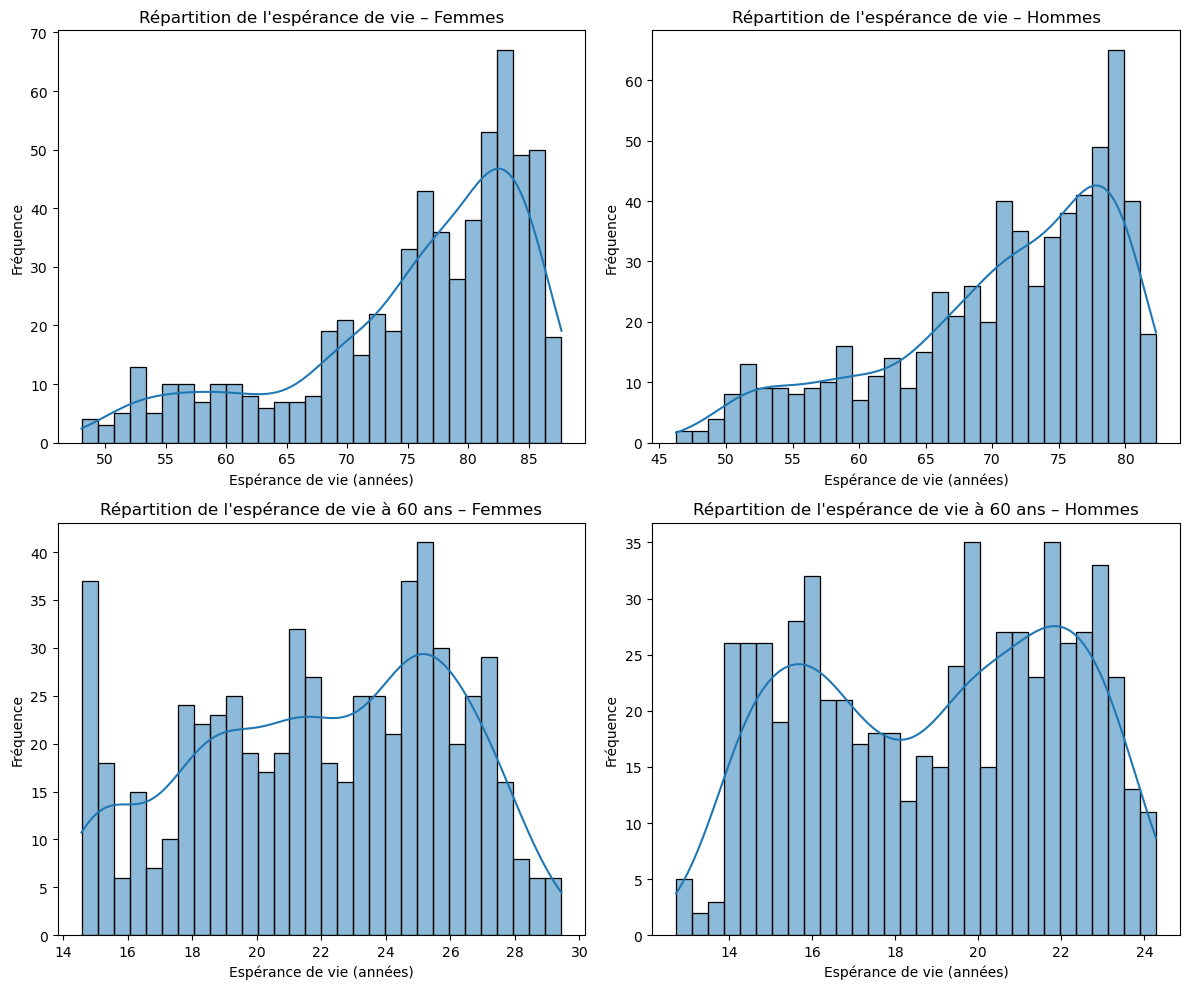

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))


plots = [
    ('LE_femmes', "Répartition de l'espérance de vie – Femmes"),
    ('LE_hommes', "Répartition de l'espérance de vie – Hommes"),
    ('LE_60_femmes', "Répartition de l'espérance de vie à 60 ans – Femmes"),
    ('LE_60_hommes', "Répartition de l'espérance de vie à 60 ans – Hommes")
]

for ax, (var, titre) in zip(axes.flat, plots):
    sns.histplot(data[var].dropna(), kde=True, bins=30, ax=ax)
    ax.set_title(titre)
    ax.set_xlabel("Espérance de vie (années)")
    ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

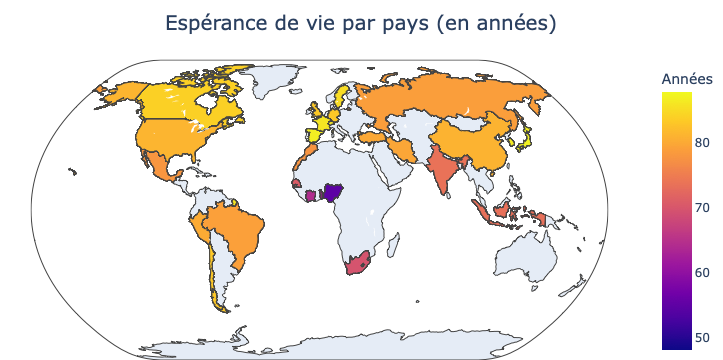

In [18]:
# Création de la carte choroplèthe
fig = px.choropleth(
    df,
    locations='Code_Pays',
    color='LE_femmes',
    hover_name='Pays',
    hover_data={
        'Espérance de vie (F)': df['LE_femmes'][:].round(1),  # Arrondi à 1 décimale
        'Espérance de vie (H)': df['LE_hommes'][:].round(1),
        'Espérance de vie à 60 ans (F)': df['LE_60_femmes'][:].round(1),
        'Espérance de vie à 60 ans (H)': df['LE_60_hommes'][:].round(1),
    },
    color_continuous_scale=px.colors.sequential.Plasma,
    projection='natural earth',
    title='Espérance de vie par pays (en années)',
)
# Personnalisation de la mise en forme
fig.update_layout(
    margin={"r": 0, "t": 60, "l": 0, "b": 0},  # Ajustement des marges pour le titre
    coloraxis_colorbar={
        'title': 'Années',  # Titre de la barre de couleur
        'tickprefix': '',   # Supprime les préfixes inutiles
        'dtick': 10,        # Intervalle de 10 ans pour les graduations
    },
    title_font_size=20,  # Taille du titre
    title_x=0.5,          # Centre le titre
)

# Affichage de la carte
fig.show()

# EDA — Analyse complète des écarts Homme/Femme

In [19]:
df["LE_WMGap"] = df["LE_femmes"] - df["LE_hommes"]
df["LE_WMGap_60"] = df["LE_60_femmes"] - df["LE_60_hommes"]


In [20]:
df.head()

,Année,Pays,Code_Pays,Statut,LE_hommes,LE_femmes,LE_60_femmes,LE_60_hommes,Mort_inf_filles,Mort_inf_garçons,...,Pop_65_69_femmes,Pop_65_69_hommes,Pop_70_74_femmes,Pop_70_74_hommes,Pop_75_79_femmes,Pop_75_79_hommes,Pop_80_plus_femmes,Pop_80_plus_hommes,LE_WMGap,LE_WMGap_60
0,2000,Afrique du Sud,ZAF,Developing,55.415,61.082,18.9311,16.1083,43.1,50.5,...,2.211204,1.537589,1.525757,1.107638,0.889006,0.661806,0.881770,0.599231,5.667,2.8228
1,2001,Afrique du Sud,ZAF,Developing,54.583,59.491,18.6864,16.0578,43.9,51.2,...,2.188845,1.477294,1.619396,1.151636,0.908636,0.666223,0.916061,0.621060,4.908,2.6286
2,2002,Afrique du Sud,ZAF,Developing,53.215,57.703,18.7287,15.9335,44.3,51.5,...,2.164919,1.425694,1.698456,1.181962,0.945997,0.679119,0.945302,0.637910,4.488,2.7952
3,2003,Afrique du Sud,ZAF,Developing,51.993,56.266,18.6059,15.6566,45.0,52.1,...,2.148864,1.394812,1.755738,1.191550,1.001445,0.700578,0.968578,0.650782,4.273,2.9493
4,2004,Afrique du Sud,ZAF,Developing,51.915,55.754,19.0619,15.9451,45.3,52.3,...,2.149692,1.393029,1.782337,1.175094,1.072526,0.729919,0.990046,0.660463,3.839,3.1168


In [21]:
df.tail()

,Année,Pays,Code_Pays,Statut,LE_hommes,LE_femmes,LE_60_femmes,LE_60_hommes,Mort_inf_filles,Mort_inf_garçons,...,Pop_65_69_femmes,Pop_65_69_hommes,Pop_70_74_femmes,Pop_70_74_hommes,Pop_75_79_femmes,Pop_75_79_hommes,Pop_80_plus_femmes,Pop_80_plus_hommes,LE_WMGap,LE_WMGap_60
619,2019,États-Unis,USA,Developed,76.3,81.4,24.9911,22.0077,5.0,6.0,...,5.388169,4.957295,4.358857,3.873608,3.063664,2.500189,4.378214,2.842773,5.1,2.9834
620,2020,États-Unis,USA,Developed,74.2,79.9,23.7455,20.6261,5.0,6.0,...,5.510473,5.069210,4.535278,4.020149,3.149193,2.604030,4.403979,2.869259,5.7,3.1194
621,2021,États-Unis,USA,Developed,73.5,79.3,23.7058,20.5484,5.0,5.9,...,5.638615,5.180133,4.663064,4.122367,3.277370,2.734821,4.442452,2.906020,5.8,3.1574
622,2022,États-Unis,USA,Developed,74.8,80.2,24.6623,21.5036,5.0,5.9,...,5.751840,5.292878,4.726596,4.169993,3.462825,2.907738,4.544033,2.999857,5.4,3.1587
623,2023,États-Unis,USA,Developed,75.8,81.1,25.3208,22.3613,5.0,5.9,...,5.855598,5.410812,4.809668,4.244839,3.640823,3.068695,4.703437,3.145309,5.3,2.9595


## Distributions des écarts H/F

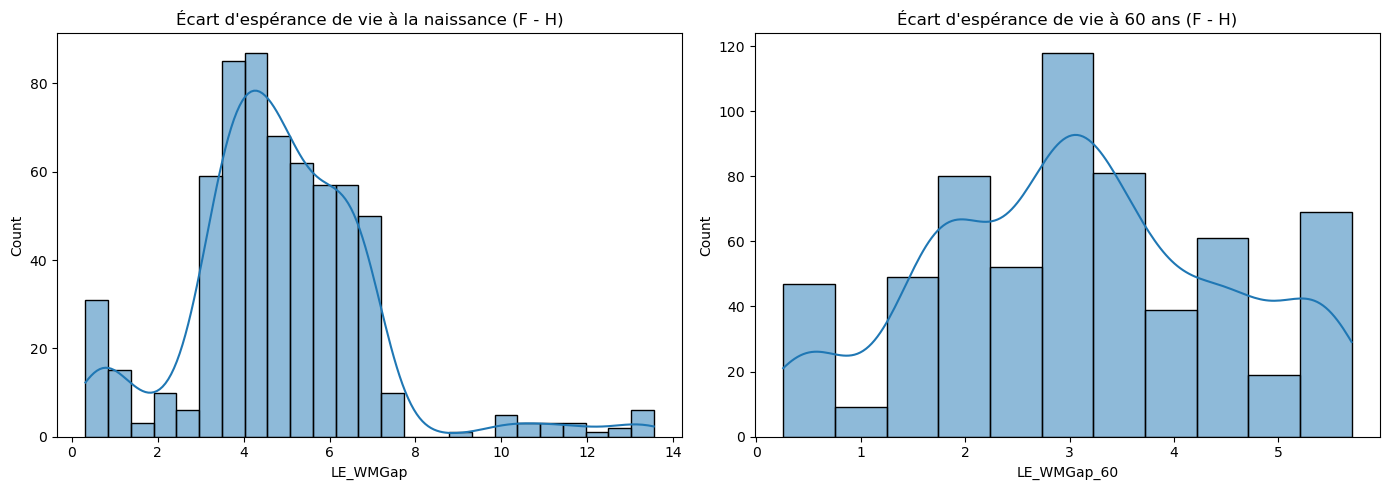

In [22]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["LE_WMGap"], kde=True, ax=axes[0])
axes[0].set_title("Écart d'espérance de vie à la naissance (F - H)")

sns.histplot(df["LE_WMGap_60"], kde=True, ax=axes[1])
axes[1].set_title("Écart d'espérance de vie à 60 ans (F - H)")

plt.tight_layout()
plt.show()


## Évolution temporelle des écarts pour quelques pays

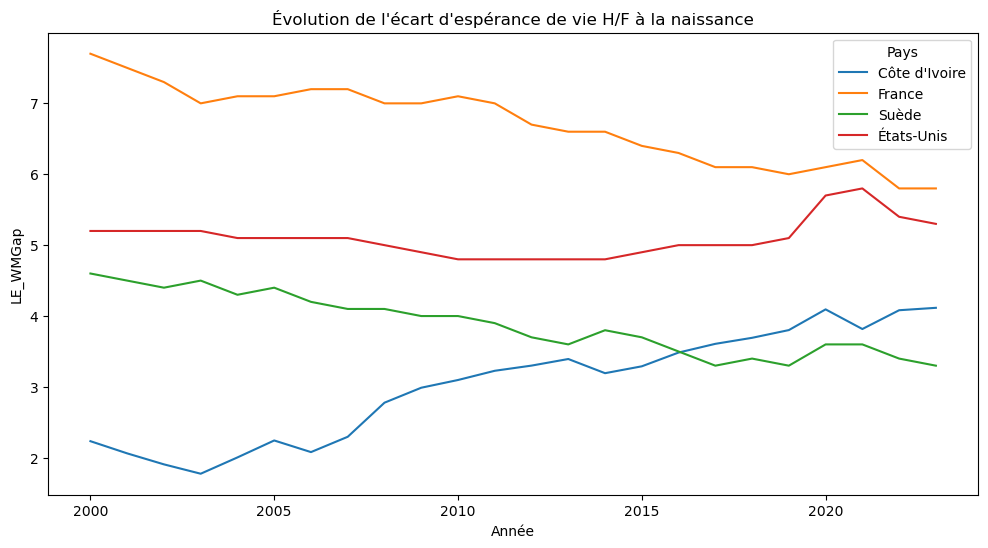

In [23]:
pays_exemples = ["France", "Côte d'Ivoire", "Suède", "États-Unis"]

subset = df[df["Pays"].isin(pays_exemples)]

plt.figure(figsize=(12,6))
sns.lineplot(data=subset, x="Année", y="LE_WMGap", hue="Pays")
plt.title("Évolution de l'écart d'espérance de vie H/F à la naissance")
plt.show()


## Comparaison Développés vs. Développement

In [29]:
sns.boxplot(data=df, x="Statut", y="Gap_vie_naissance")
plt.title("Écart H/F par statut de développement")
plt.show()

ValueError: Could not interpret value `Gap_vie_naissance` for `y`. An entry with this name does not appear in `data`.

## Corrélation des écarts avec les déterminants

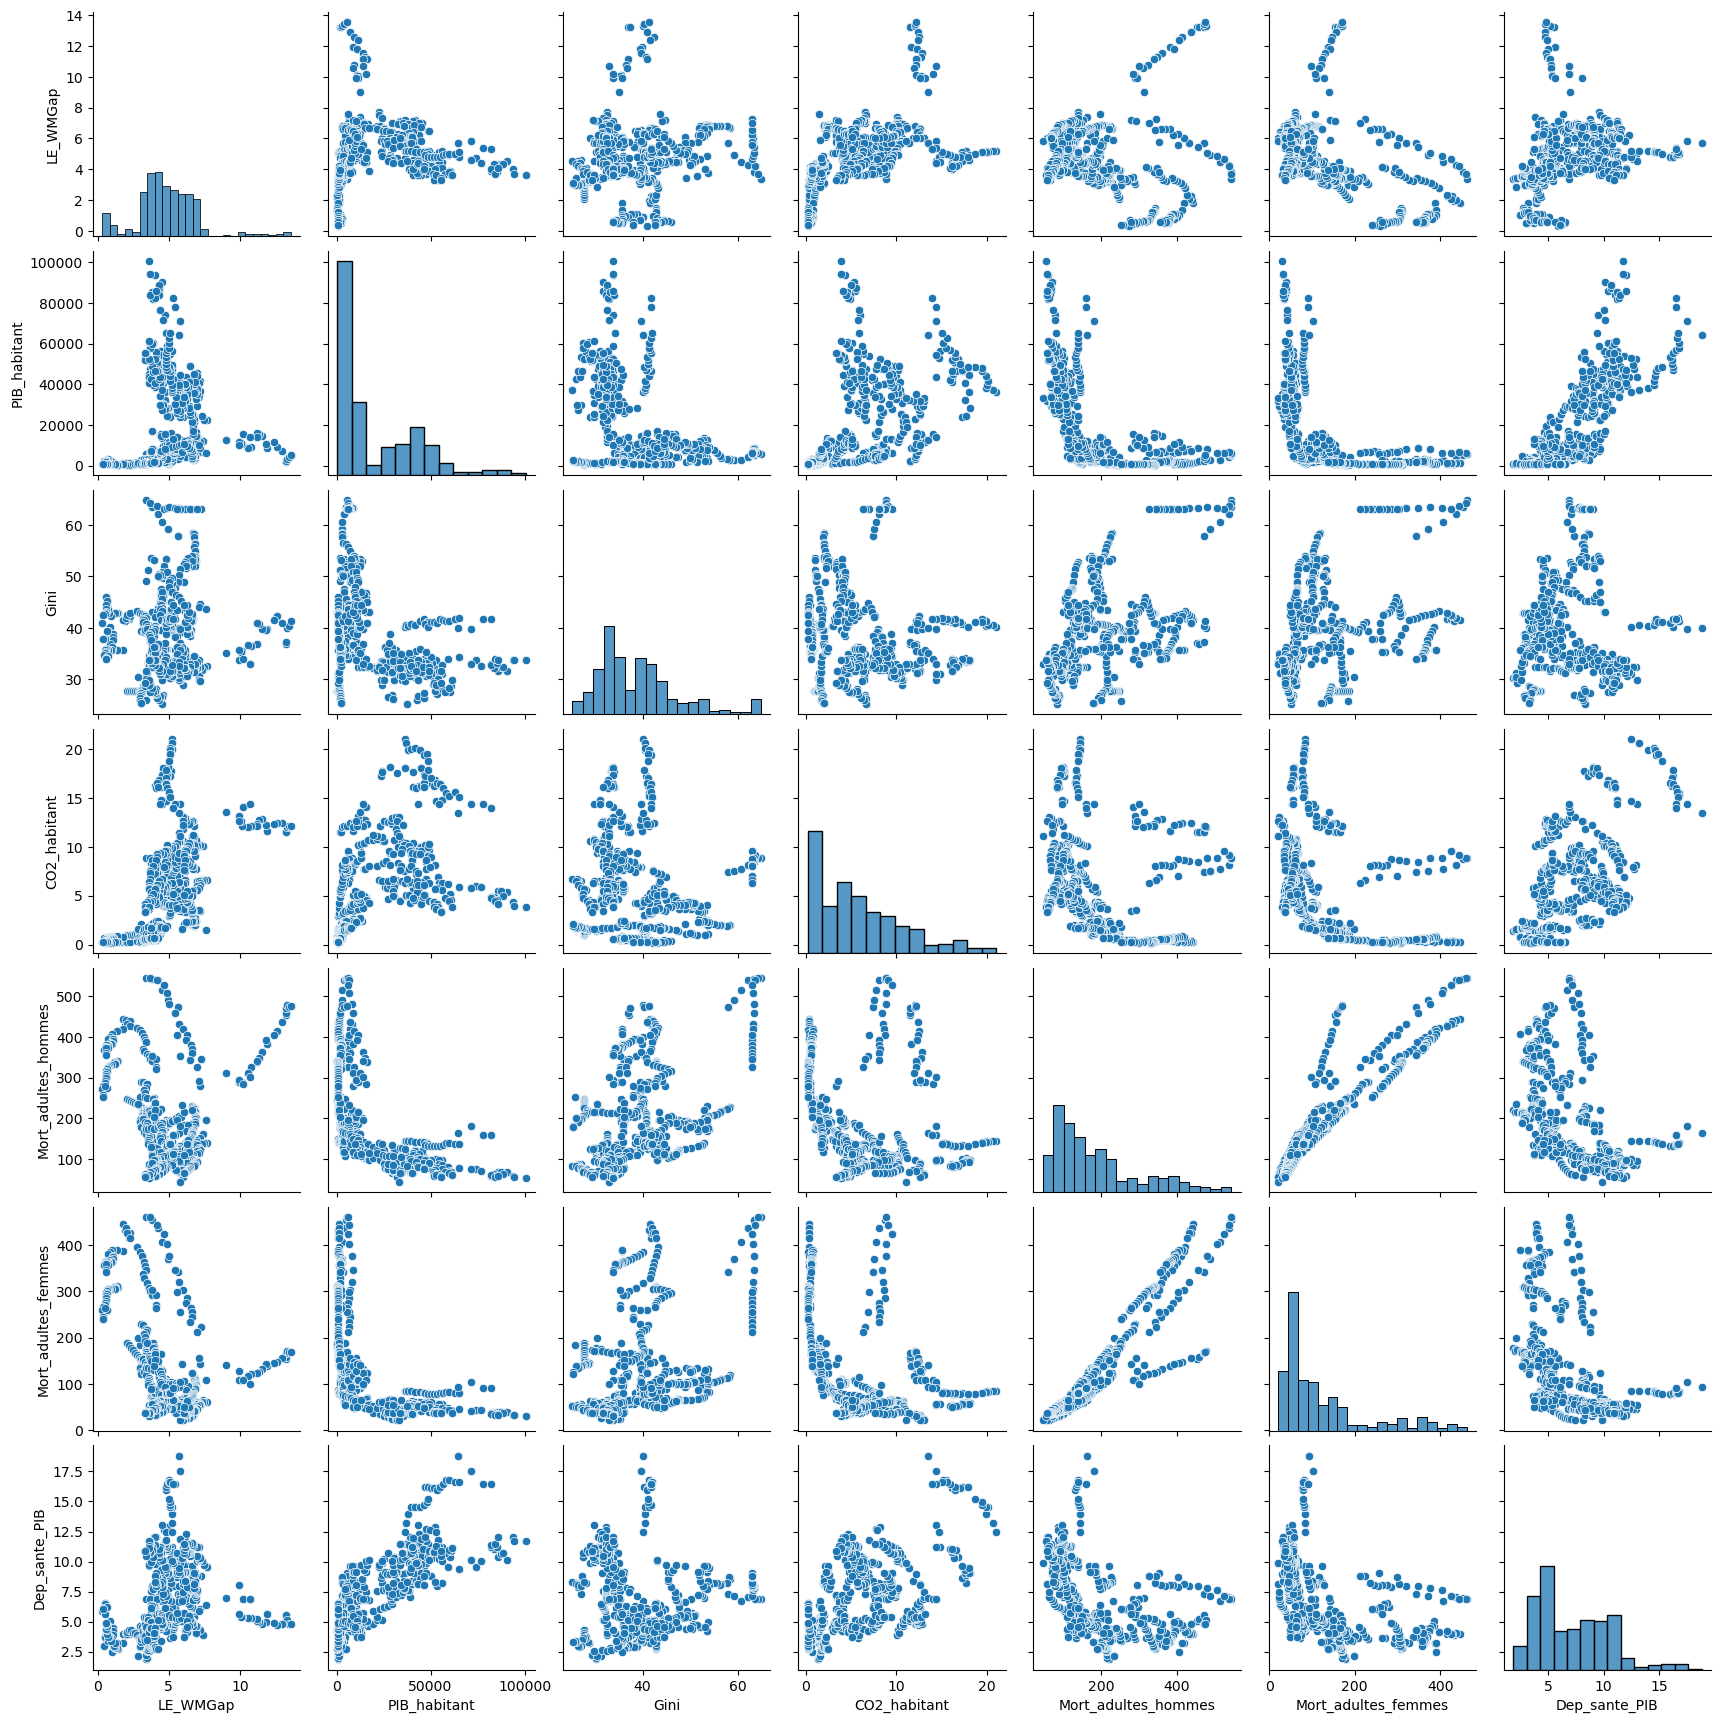

In [30]:
variables = ["LE_WMGap", "PIB_habitant", "Gini", "CO2_habitant", 
             "Mort_adultes_hommes", "Mort_adultes_femmes", "Dep_sante_PIB"]

sns.pairplot(df[variables].dropna())
plt.show()


In [31]:
### Matrice de corrélations 

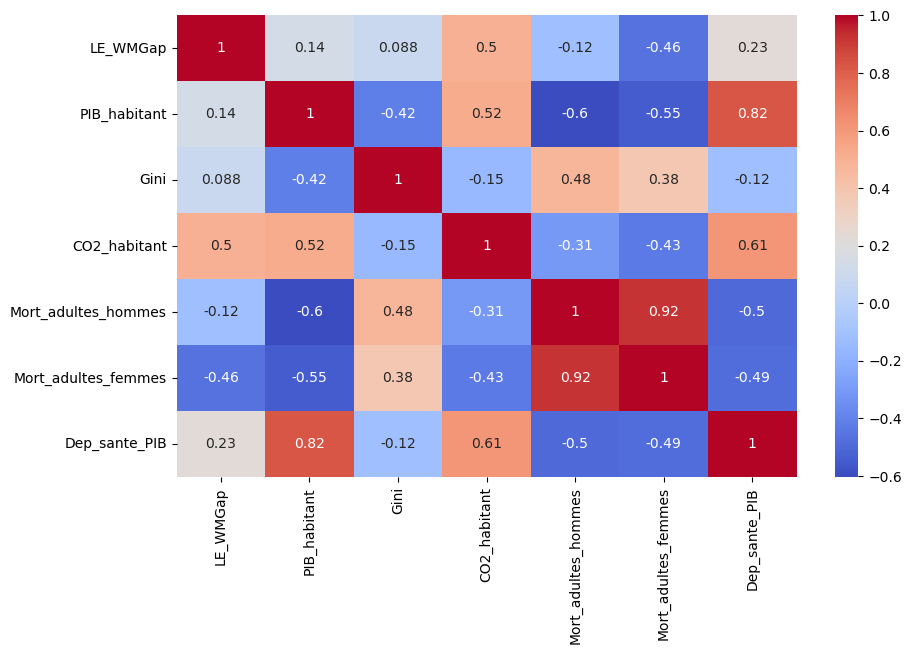

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(df[variables].corr(), annot=True, cmap="coolwarm") 
plt.show()


In [33]:
df.columns

Index(['Année', 'Pays', 'Code_Pays', 'Statut', 'LE_hommes', 'LE_femmes',
       'LE_60_femmes', 'LE_60_hommes', 'Mort_inf_filles', 'Mort_inf_garçons',
       'PIB_habitant', 'Gini', 'Mort_adultes_hommes', 'Mort_adultes_femmes',
       'Chomage_femmes', 'Chomage_hommes', 'CO2_habitant', 'Taux_naissance',
       'Pop_15_64_hommes', 'Pop_15_64_femmes', 'Dep_sante_PIB',
       'Mort_prem_femmes', 'Mort_prem_hommes', 'Incidence_VIH',
       'Prevalence_VIH', 'Pop_0_4_filles', 'Pop_0_4_garçons', 'Pop_5_9_filles',
       'Pop_5_9_garçons', 'Pop_10_14_filles', 'Pop_10_14_garçons',
       'Pop_15_19_filles', 'Pop_15_19_garçons', 'Pop_20_24_femmes',
       'Pop_20_24_hommes', 'Pop_25_29_femmes', 'Pop_25_29_hommes',
       'Pop_30_34_femmes', 'Pop_30_34_hommes', 'Pop_35_39_femmes',
       'Pop_35_39_hommes', 'Pop_40_44_femmes', 'Pop_40_44_hommes',
       'Pop_45_49_femmes', 'Pop_45_49_hommes', 'Pop_50_54_femmes',
       'Pop_50_54_hommes', 'Pop_55_59_femmes', 'Pop_55_59_hommes',
       'Pop_60_64

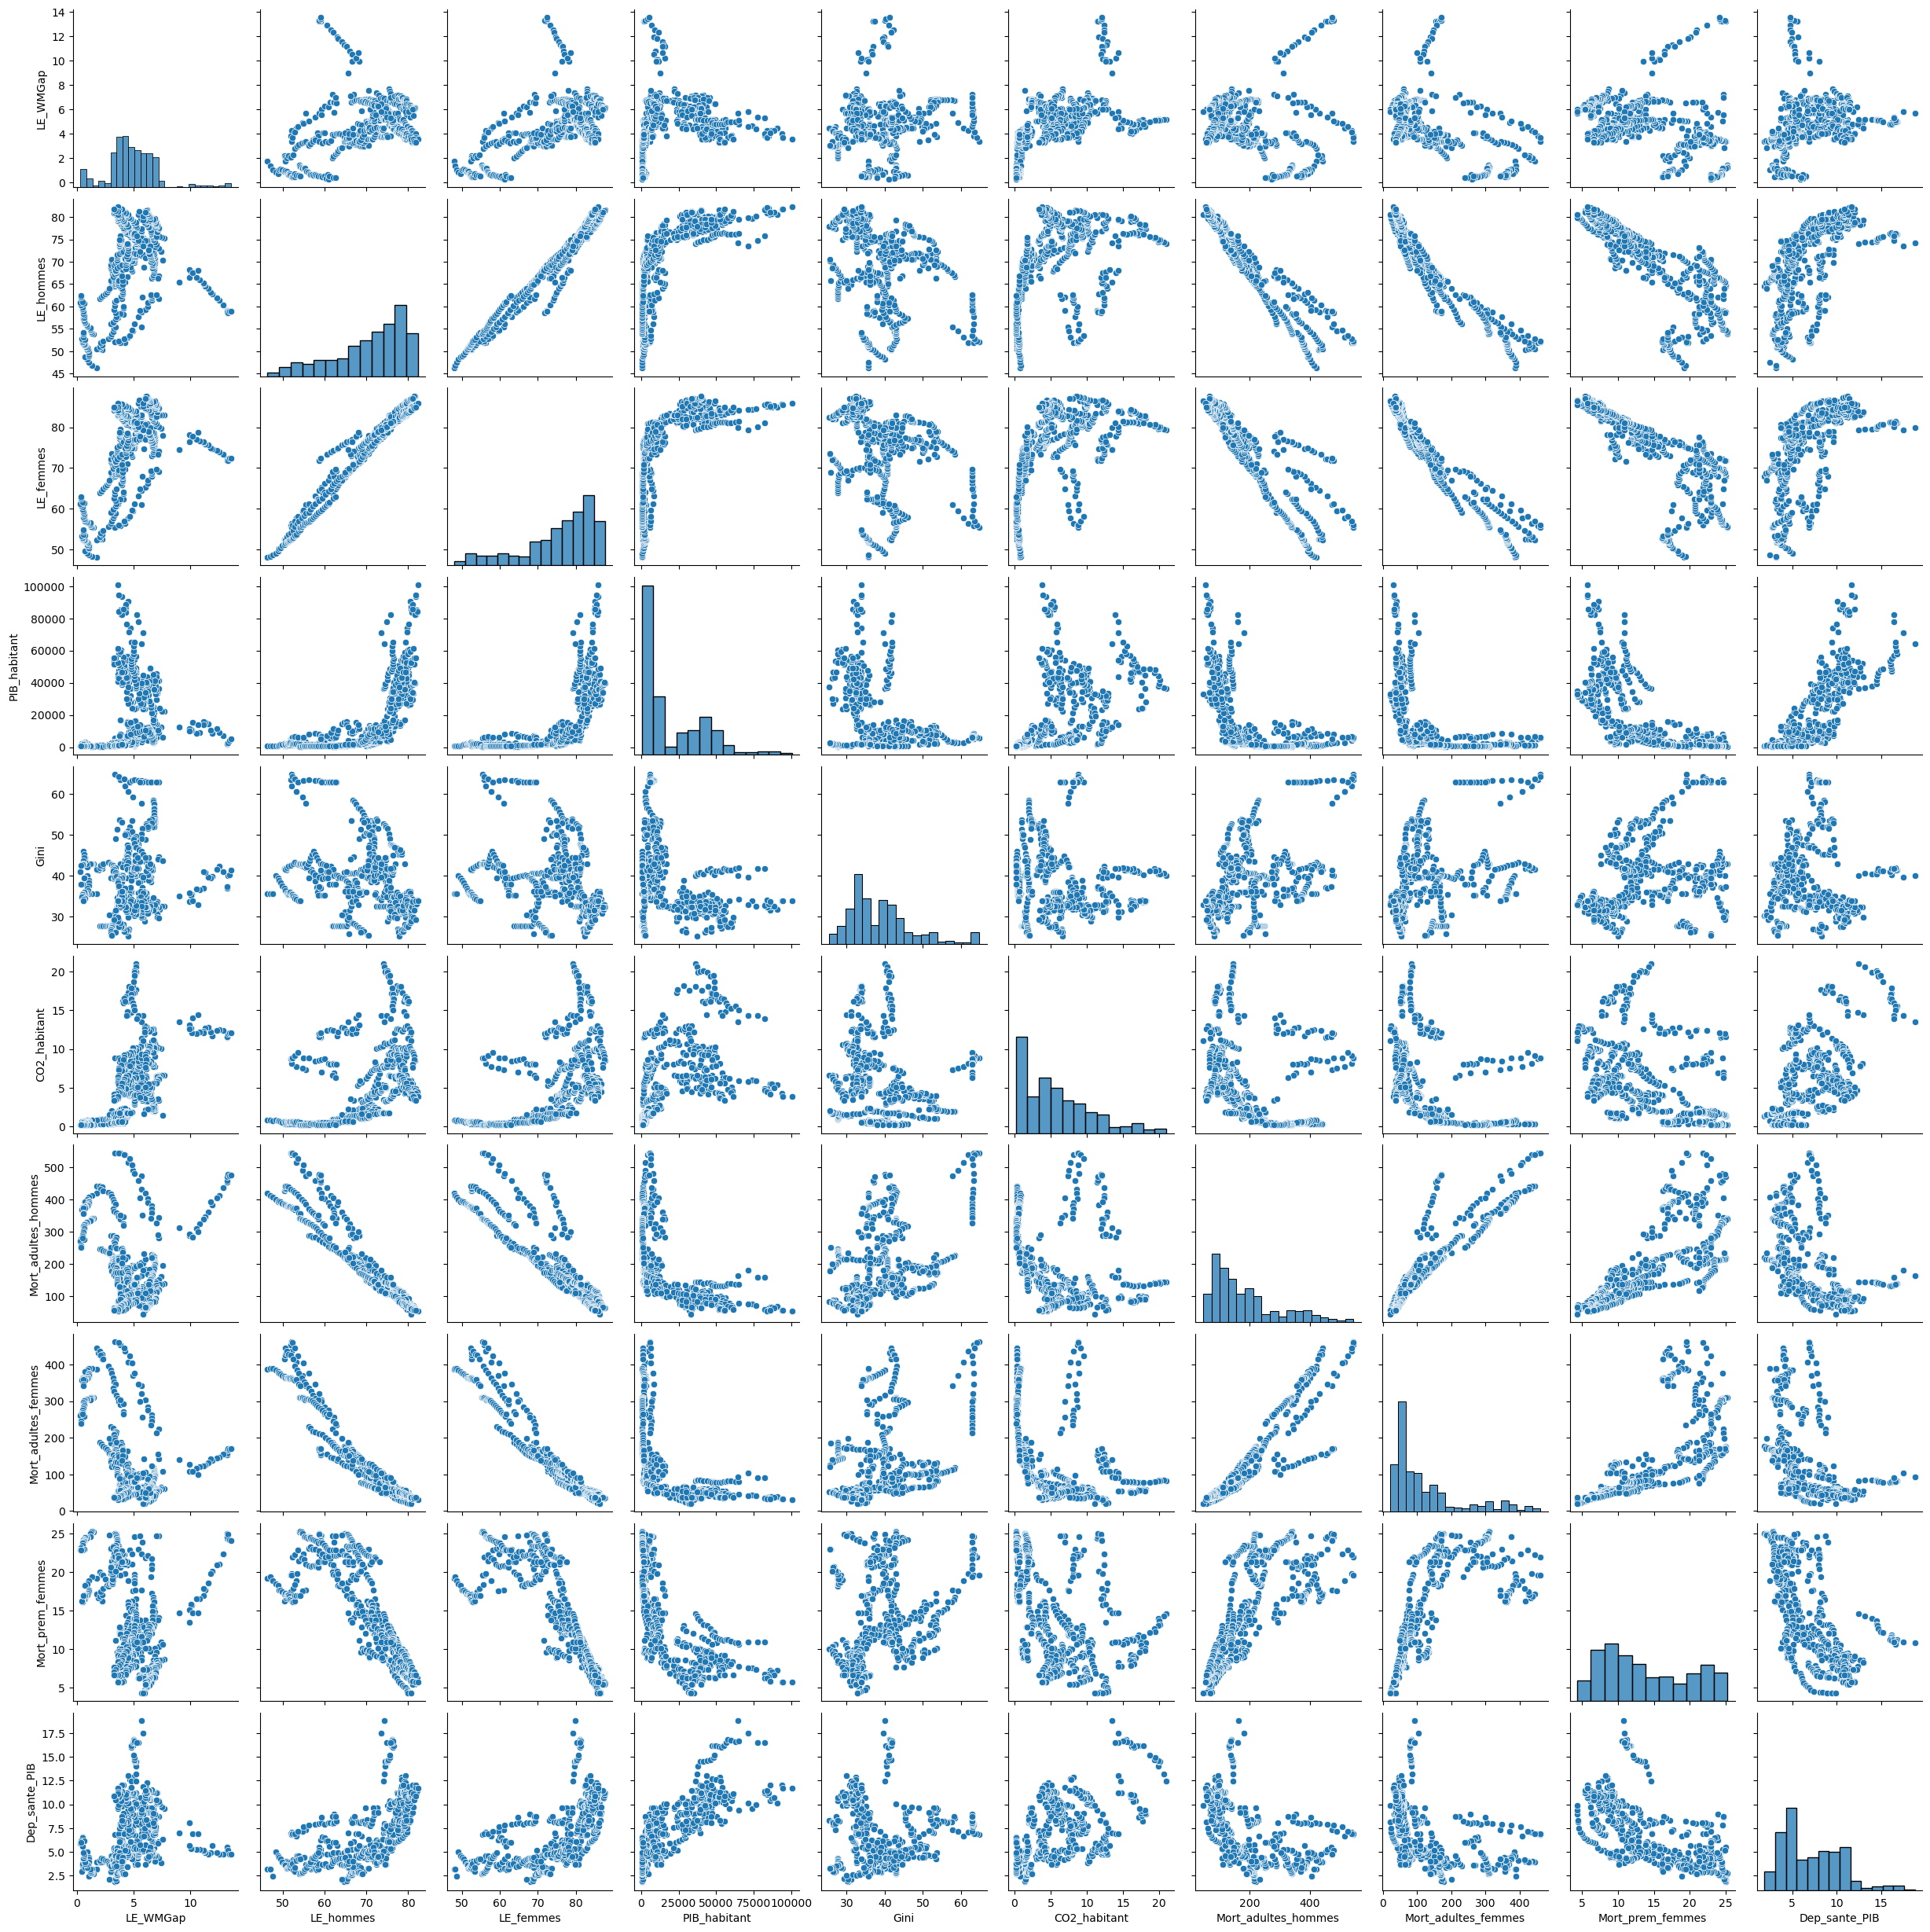

In [34]:
variables = ["LE_WMGap", "LE_hommes","LE_femmes","PIB_habitant", "Gini", "CO2_habitant", 
             "Mort_adultes_hommes", "Mort_adultes_femmes", "Mort_prem_femmes","Dep_sante_PIB"]

sns.pairplot(df[variables].dropna())
plt.show()

In [35]:
df1 = pd.read_csv("BdAPI2.csv")
#Trier les données par pays et par année
df1 = df1.sort_values(by=["Pays", "Année"])
df1.head()

FileNotFoundError: [Errno 2] No such file or directory: 'BdAPI2.csv'

In [ ]:
df1 = df1.rename(columns = {"Dépenses publiques générales de santé (% des dépenses courantes de santé)" : "DPGS(%DCS)"})
df1.head()

In [ ]:
df1 = df1.drop("Espérance de vie à la naissance, hommes (années)", axis=1)
df1.head()

In [ ]:
df_merged = pd.merge(df, df1, on=["Pays", "Année"], how="inner")
df_merged.head()

In [ ]:
df_merged.columns

In [ ]:
df_merged = df_merged.drop(
    ["Code Pays", "Chomage_femmes", "Chomage_hommes", "CO2_habitant",
     "Taux_naissance", "Pop_15_64_hommes", "Pop_15_64_femmes",
     "Mort_prem_femmes", "Mort_prem_hommes", "Incidence_VIH",
     "Prevalence_VIH"],
    axis=1
)

df_merged.head()

In [ ]:
df_merged.columns

In [ ]:
df_merged.to_csv("DataBM.csv", index=False, sep=";")
